## **Project Overview**  
This project aims to predict house prices using machine learning models. The dataset consists of numerical and categorical features that influence housing prices. The workflow includes data preprocessing, feature engineering, model training, and evaluation to determine the best-performing model.  

## **Steps Followed**  

### **1️⃣ Data Preparation**  
- Imported essential libraries (`numpy`, `pandas`, `matplotlib`, `seaborn`, `sklearn`).  
- Loaded the dataset and examined its structure.  
- Identified feature types (numerical, categorical) and handled missing values.  

### **2️⃣ Exploratory Data Analysis (EDA)**  
- Plotted scatterplots to identify trends and outliers.  
- Generated a correlation heatmap to find the most important features.  
- Analyzed the `SalePrice` distribution to check for skewness.  

### **3️⃣ Feature Engineering**  
Created new features to enhance model performance:  
- **`HouseAge`** = `YrSold` - `YearBuilt` (Age of house since built)  
- **`HouseRemodelAge`** = `YrSold` - `YearRemodAdd` (Years since last remodel)  
- **`TotalSF`** = `1stFlrSF` + `2ndFlrSF` + `BsmtFinSF1` + `BsmtFinSF2` (Total square footage)  
- **`TotalArea`** = `GrLivArea` + `TotalBsmtSF` (Total living + basement area)  
- **`TotalBaths`** = `BsmtFullBath` + `FullBath` + `0.5 * (BsmtHalfBath + HalfBath)` (Total bathrooms, where half baths count as 0.5)  
- **`TotalPorchSF`** = `OpenPorchSF` + `3SsnPorch` + `EnclosedPorch` + `ScreenPorch` + `WoodDeckSF` (Total porch and deck space)  
- Dropped irrelevant or highly correlated features.  

### **4️⃣ Data Preprocessing**  
- **Categorical Features**  
  - Ordinal features → Encoded using `OrdinalEncoder`.  
  - Nominal features → Applied `OneHotEncoding`.  
- **Numerical Features**  
  - Handled missing values.  
  - Standardized using `StandardScaler`.  
- Combined all transformations using `ColumnTransformer`.  

### **5️⃣ Target Variable Transformation**  
- Applied log transformation: `np.log1p(SalePrice)` to normalize the target variable.  

### **6️⃣ Model Training & Evaluation**  
Split data into **80% training / 20% testing** and trained multiple models:  
✅ **Linear Regression**  
✅ **Random Forest Regressor** (with `GridSearchCV` for hyperparameter tuning)  
✅ **XGBoost**  
✅ **Ridge Regression**  
✅ **Gradient Boosting Regressor**  
✅ **LGBM Regressor** (with Cross Validation)  
✅ **CatBoost Regressor**  

**Evaluation Metric:** Root Mean Squared Error (RMSE)  

### **7️⃣ Stacking Model for Final Prediction**  
- Combined multiple models using **Stacking Regressor** to improve performance.  
- Generated final predictions on the test set.  

### **8️⃣ Submission**  
- Converted predictions back to the original scale using `np.exp()`.  
- Created a submission file (`CSV`) containing the predicted `SalePrice`.  

## **📂 Technologies Used**  
- **Python** (`pandas`, `numpy`, `matplotlib`, `seaborn`)  
- **Scikit-learn** (`LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, `GridSearchCV`)  
- **XGBoost, CatBoost, LGBM**  
- **Feature Engineering & Data Preprocessing** (`ColumnTransformer`, `OneHotEncoding`, `StandardScaler`)  


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostClassifier
from sklearn.kernel_ridge import KernelRidge

In [2]:
train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train_df.shape

(1460, 81)

1460 samples (rows): These represent the number of observations or data points in your dataset.
81 features (columns): These are the attributes, variables, or characteristics for each sample.

In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train_df.dtypes[train_df.dtypes != 'object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

## Plot relationship between input features and 'SalePrice'
- query the outlier
  

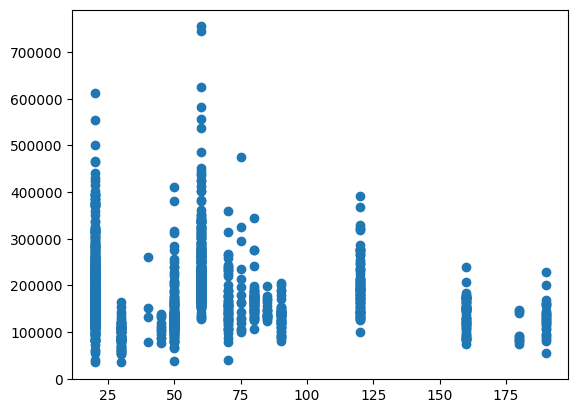

In [8]:
plt.scatter(x='MSSubClass',y='SalePrice', data=train_df)

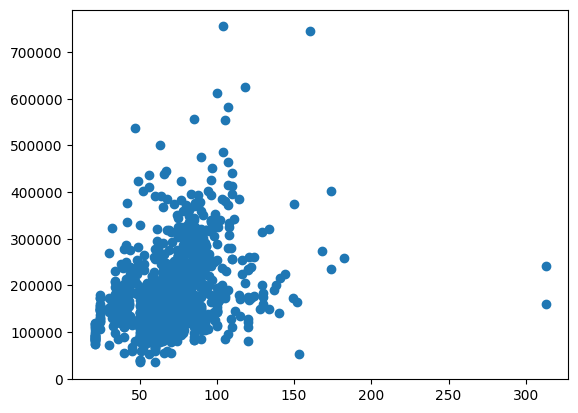

In [9]:
plt.scatter(x='LotFrontage',y='SalePrice', data=train_df)

In [10]:
train_df.query('LotFrontage > 300')
# outlier: id 935 and 1299 > 300

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


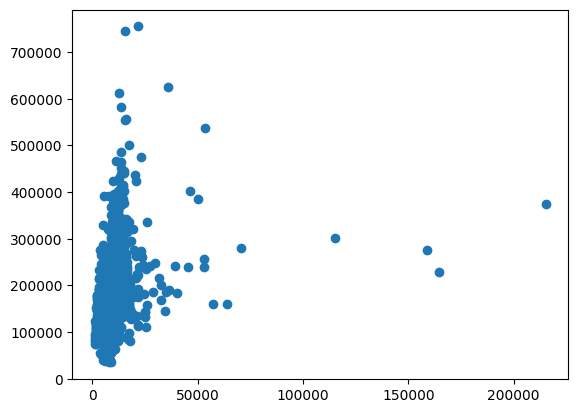

In [11]:
plt.scatter(x='LotArea',y='SalePrice', data=train_df)

In [12]:
train_df.query('LotArea > 55000')
# id 250, 314,336, 707  maybe 57200

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [13]:
stats.zscore(train_df['LotArea']). sort_values().tail(10)

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
Name: LotArea, dtype: float64

Skewness: 1.8809

A skewness value of 1.88 indicates the distribution is positively skewed (right-skewed).
Rule of thumb:
Skewness between -0.5 to 0.5: Approximately symmetric.
Skewness between 0.5 to 1 or -0.5 to -1: Moderately skewed.
Skewness > 1 or < -1: Highly skewed.
Since the value is above 1, it confirms significant right skewness.

Kurtosis: 6.5098

Kurtosis measures the "tailedness" of the distribution.
Rule of thumb:
Kurtosis = 3: Normal distribution (mesokurtic).
Kurtosis > 3: Heavy tails or sharp peak (leptokurtic).
Kurtosis < 3: Light tails or flat peak (platykurtic).
A kurtosis of 6.51 indicates the distribution has heavier tails and a sharper peak than a normal distribution. This is common in skewed datasets like housing prices, incomes, etc.



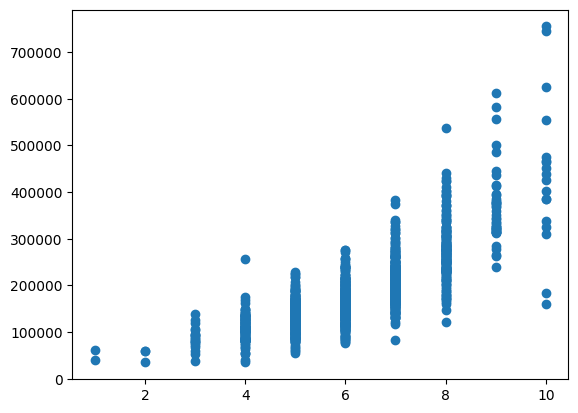

In [14]:
plt.scatter(x='OverallQual',y='SalePrice', data=train_df)

In [15]:
train_df.query('OverallQual == 10')
#maybe 524

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


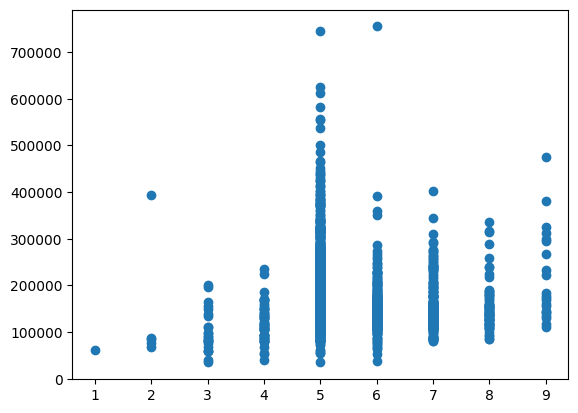

In [16]:
plt.scatter(x='OverallCond',y='SalePrice', data=train_df)
 

In [17]:
train_df.query('OverallCond == 2')
#379

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
250,251,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
676,677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000


In [18]:
train_df.query('OverallCond == 5 & SalePrice > 700000')
#`1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [19]:
train_df.query('OverallCond == 6 & SalePrice > 700000')
#`692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


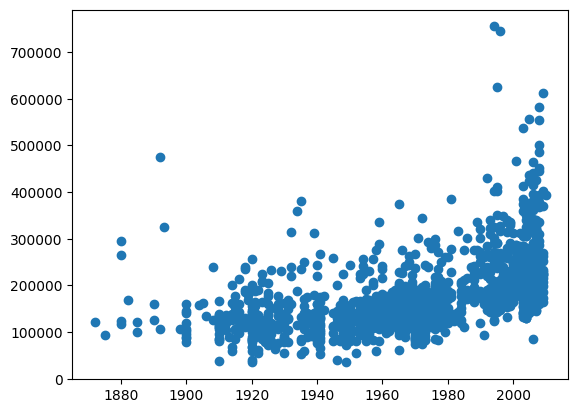

In [20]:
plt.scatter(x='YearBuilt',y='SalePrice', data=train_df)
 

In [21]:
train_df.query('YearBuilt<1900 & SalePrice >400000')
#186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


In [22]:
train_df.query('YearBuilt < 2000 & SalePrice > 700000')
#692, 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


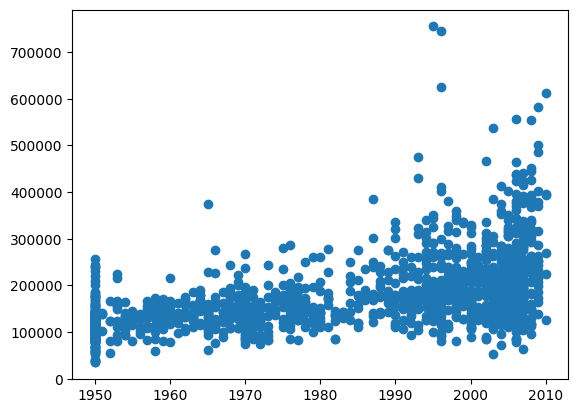

In [23]:
plt.scatter(x='YearRemodAdd',y='SalePrice', data=train_df)

In [24]:
train_df.query('YearRemodAdd < 1970  & SalePrice > 300000')
#314

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000


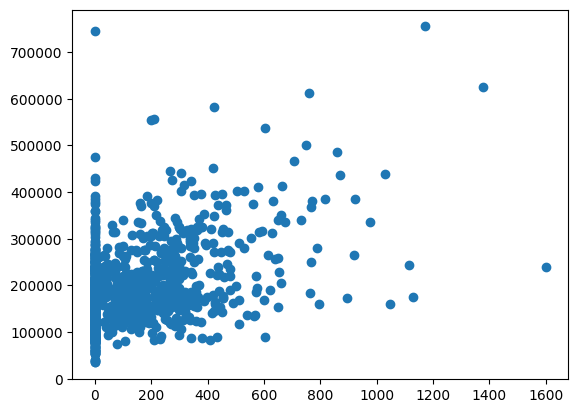

In [25]:
plt.scatter(x='MasVnrArea',y='SalePrice', data=train_df)

In [26]:
train_df.query('MasVnrArea > 100 & SalePrice > 700000')
#298, 
#1183, 692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


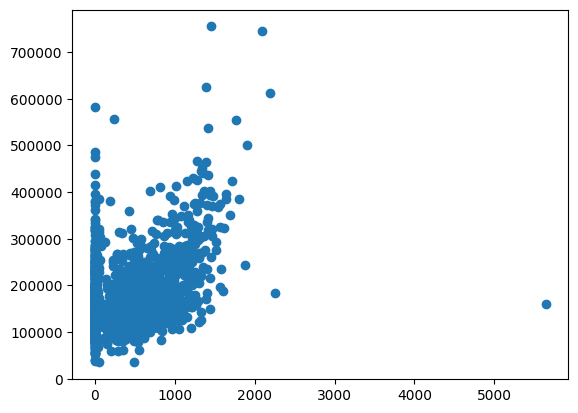

In [27]:
plt.scatter(x='BsmtFinSF1',y='SalePrice', data=train_df)

In [28]:
train_df.query('BsmtFinSF1 > 5000')
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


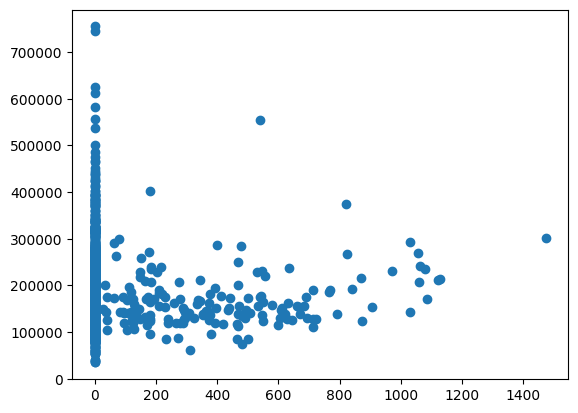

In [29]:
plt.scatter(x='BsmtFinSF2',y='SalePrice', data=train_df)

In [30]:
train_df.query('BsmtFinSF2 > 400 & SalePrice > 500000')
#441

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


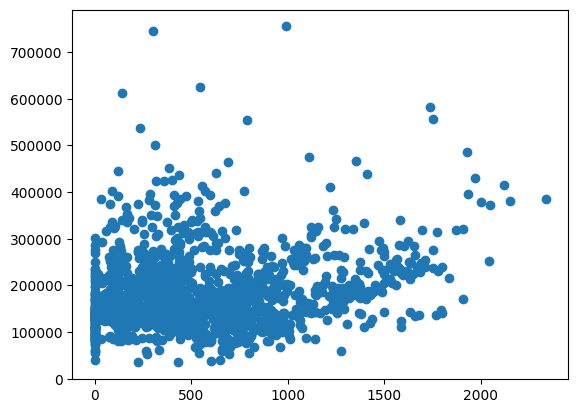

In [31]:
plt.scatter(x='BsmtUnfSF',y='SalePrice', data=train_df)

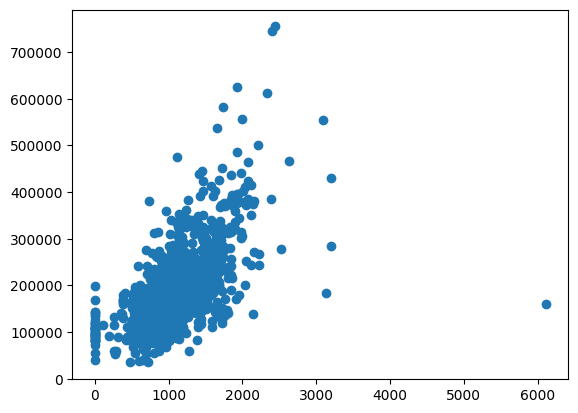

In [32]:
plt.scatter(x='TotalBsmtSF',y='SalePrice', data=train_df)

In [33]:
train_df.query('TotalBsmtSF> 6000')
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


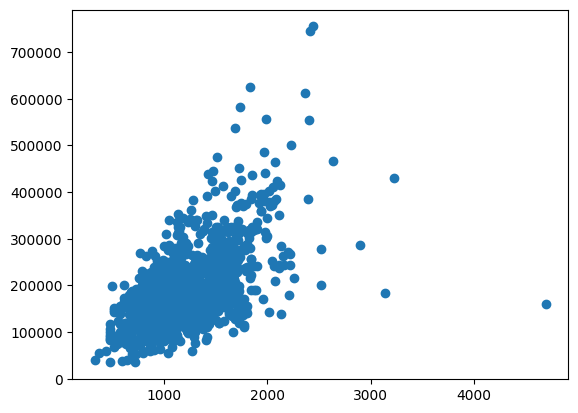

In [34]:
plt.scatter(x='1stFlrSF',y='SalePrice', data=train_df)

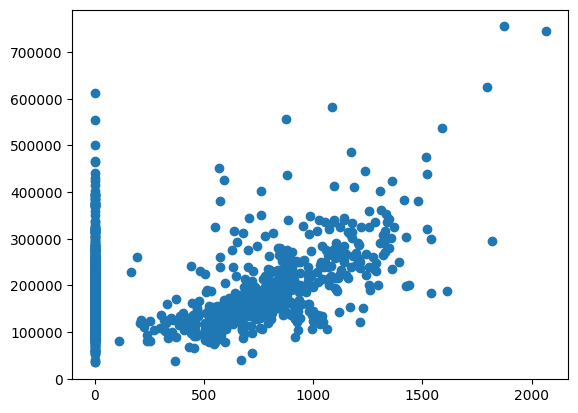

In [35]:
plt.scatter(x='2ndFlrSF',y='SalePrice', data=train_df)

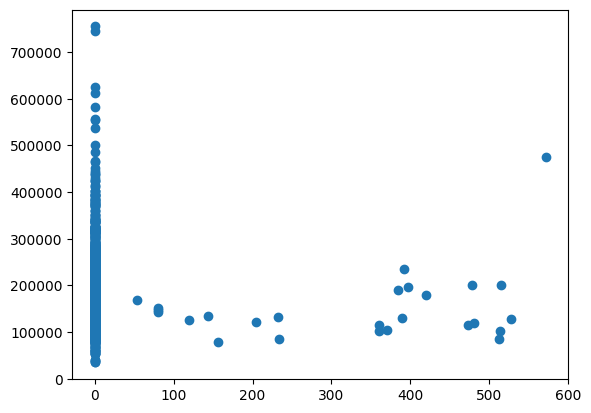

In [36]:
plt.scatter(x='LowQualFinSF',y='SalePrice', data=train_df)

In [37]:
train_df.query('LowQualFinSF> 570')
#186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


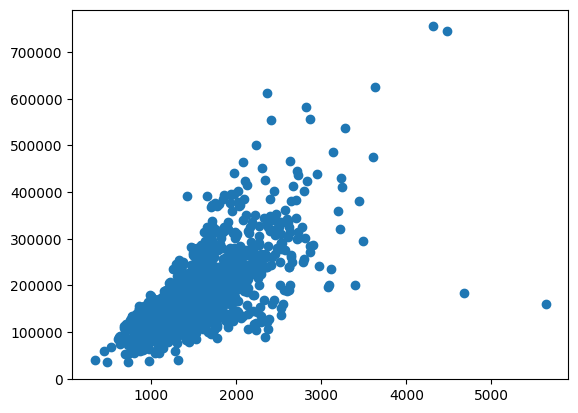

In [38]:
plt.scatter(x='GrLivArea',y='SalePrice', data=train_df)

In [39]:
train_df.query('GrLivArea > 4000')
#524,1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


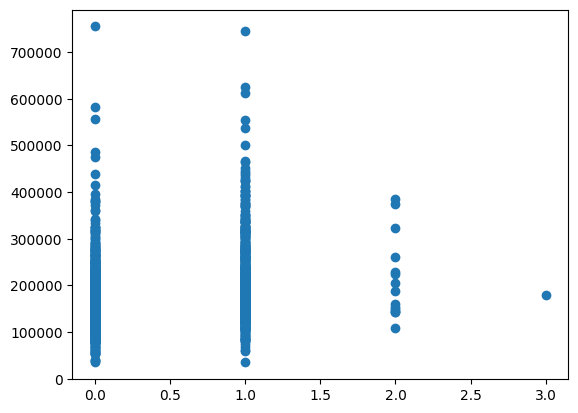

In [40]:
plt.scatter(x='BsmtFullBath',y='SalePrice', data=train_df)

In [41]:
train_df.query('BsmtFullBath == 3.0')
#739

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


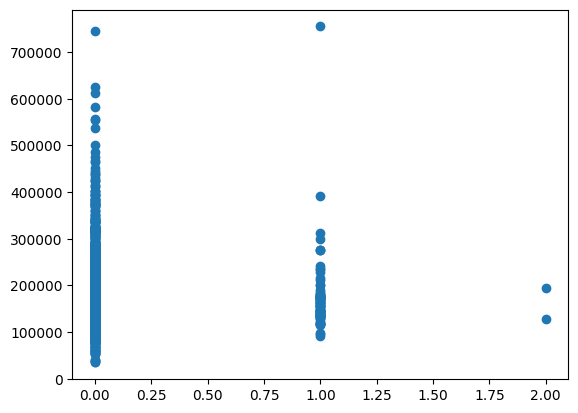

In [42]:
plt.scatter(x='BsmtHalfBath',y='SalePrice', data=train_df)

In [43]:
stats.zscore(train_df['BsmtHalfBath']).unique()

array([-0.24106104,  3.94880935,  8.13867973])

In [44]:
train_df.query('BsmtHalfBath == 2.00')
#598,955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


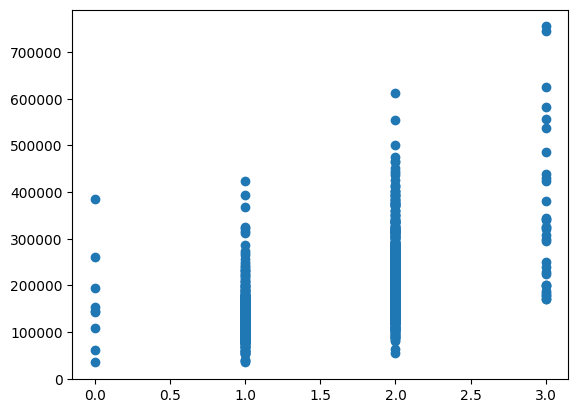

In [45]:
plt.scatter(x='FullBath',y='SalePrice', data=train_df)

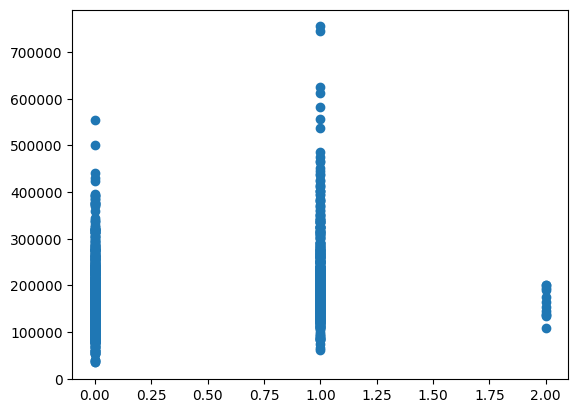

In [46]:
plt.scatter(x='HalfBath',y='SalePrice', data=train_df)

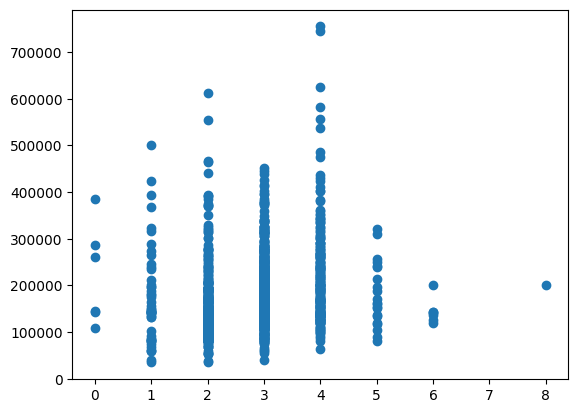

In [47]:
plt.scatter(x='BedroomAbvGr',y='SalePrice', data=train_df)

In [48]:
train_df.query('BedroomAbvGr == 8')
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


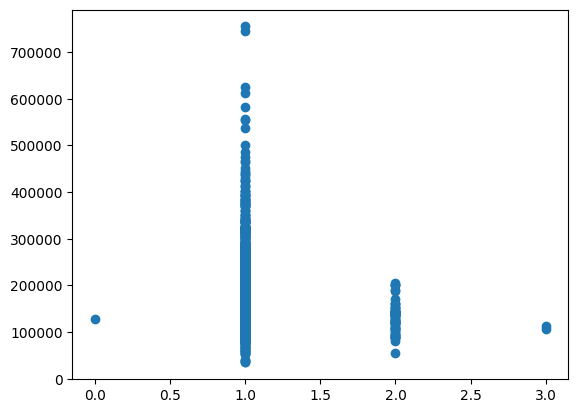

In [49]:
plt.scatter(x='KitchenAbvGr',y='SalePrice', data=train_df)

In [50]:
train_df.query('KitchenAbvGr == 3')
#49,810

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000


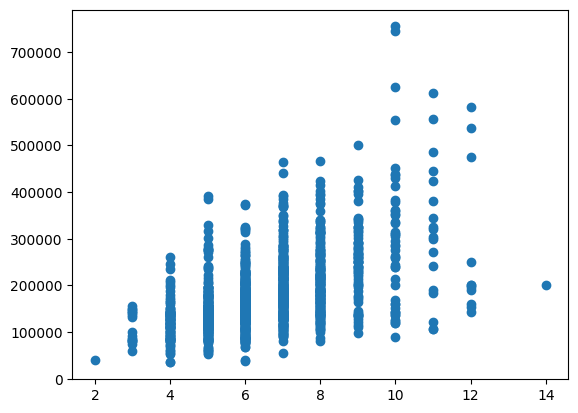

In [51]:
plt.scatter(x='TotRmsAbvGrd', y= 'SalePrice', data=train_df)

In [52]:
train_df.query('TotRmsAbvGrd == 14')
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


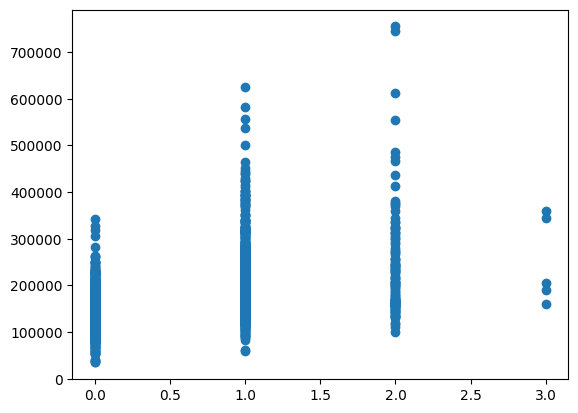

In [53]:
plt.scatter(x='Fireplaces',y='SalePrice', data=train_df)

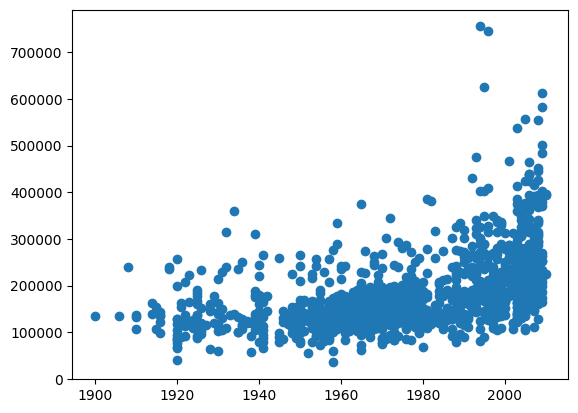

In [54]:
plt.scatter(x='GarageYrBlt',y='SalePrice', data=train_df)

In [55]:
train_df.query('GarageYrBlt < 2000 & SalePrice > 700000')
#692, 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


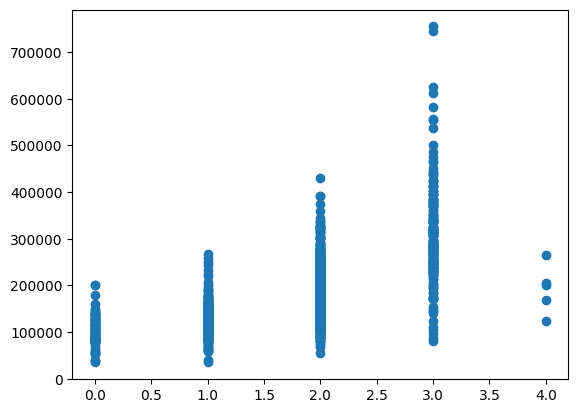

In [56]:
plt.scatter(x='GarageCars',y='SalePrice', data=train_df)

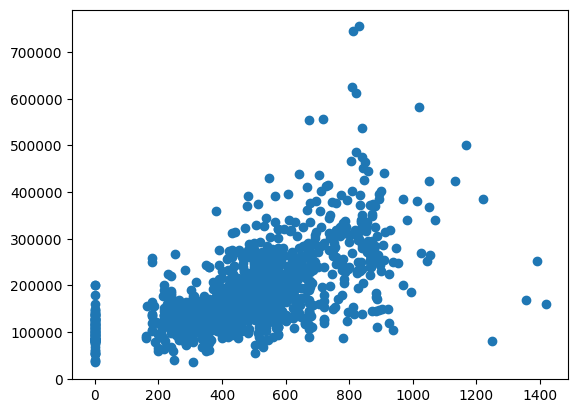

In [57]:
plt.scatter(x='GarageArea',y='SalePrice', data=train_df)

In [58]:
train_df.query('GarageArea > 1200')
#1062,1191

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


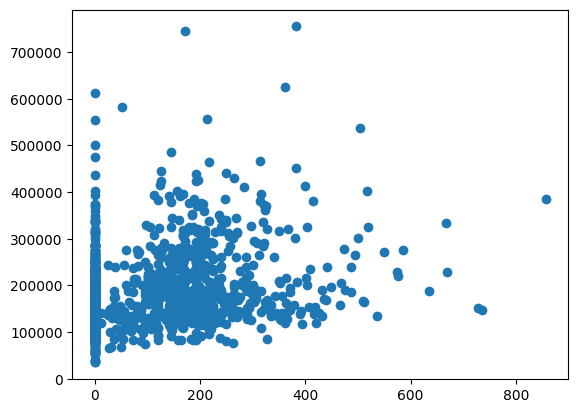

In [59]:
plt.scatter(x='WoodDeckSF',y='SalePrice', data=train_df)

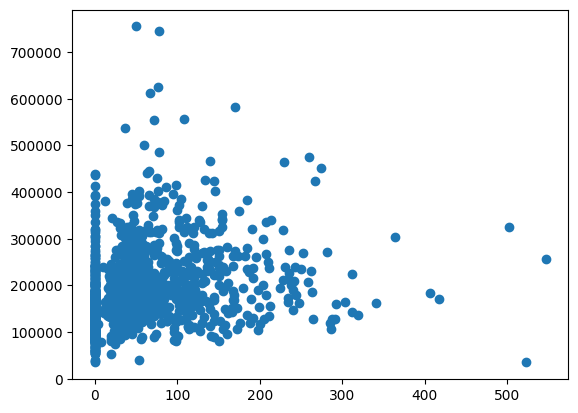

In [60]:
plt.scatter(x='OpenPorchSF',y='SalePrice', data=train_df)

In [61]:
train_df.query('OpenPorchSF > 500')
#496

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000


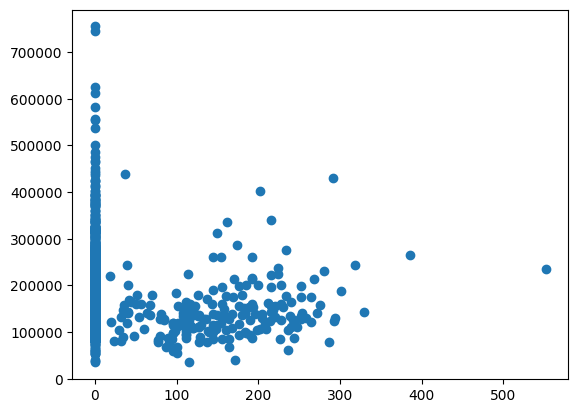

In [62]:
plt.scatter(x='EnclosedPorch',y='SalePrice', data=train_df)

In [63]:
train_df.query('EnclosedPorch > 500')
#198

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


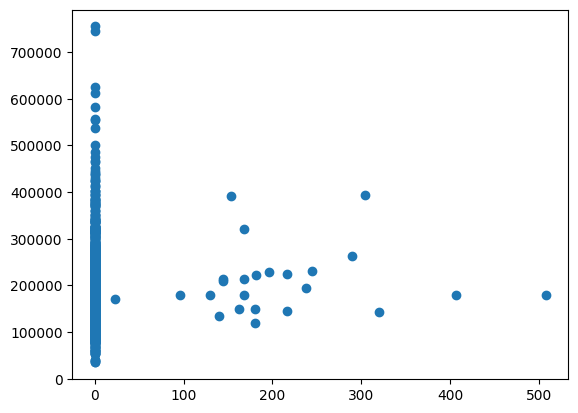

In [64]:
plt.scatter(x='3SsnPorch',y='SalePrice', data=train_df)

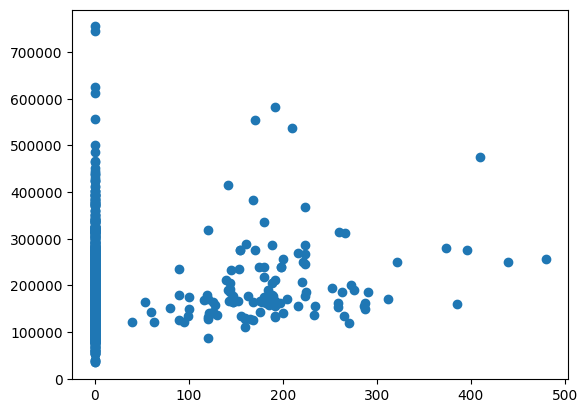

In [65]:
plt.scatter(x='ScreenPorch',y='SalePrice', data=train_df)

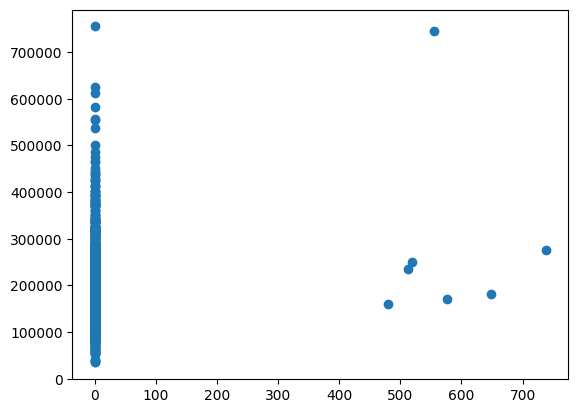

In [66]:
plt.scatter(x='PoolArea',y='SalePrice', data=train_df)

## Removing outliers we found 

In [67]:
values = ([598,955,935,1299,250,314,336,707,379,1183,692,186,441,186,524,739,598,955,636,1062,1191,49,496,198])

In [68]:

train_df = train_df[train_df.Id.isin(values) == False]

## Identifies the TOP 20 columns in train.df with the most missing values. 

In [69]:
# identifies the top 20 columns in train_df with the most missing values

pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False)).head(20)

,0
PoolQC,1435
MiscFeature,1388
Alley,1349
Fence,1162
MasVnrType,861
FireplaceQu,684
LotFrontage,255
GarageYrBlt,76
GarageCond,76
GarageType,76


In [70]:
train_df['MiscFeature'].unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [71]:
train_df['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [72]:
train_df['Alley'].fillna('No', inplace=True)
test_df['Alley'].fillna('No', inplace=True)

/tmp/ipykernel_30/2277165759.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Alley'].fillna('No', inplace=True)
/tmp/ipykernel_30/2277165759.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

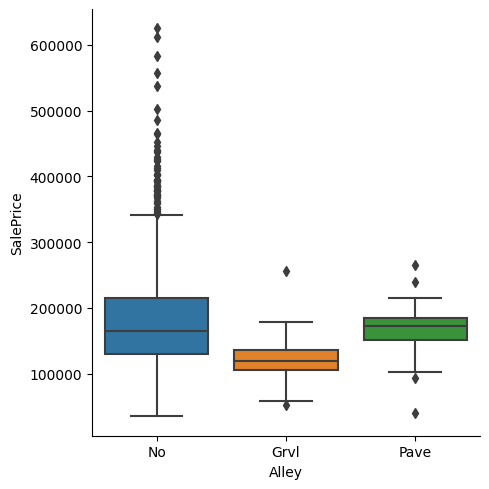

In [73]:
sns.catplot(data=train_df, x="Alley", y="SalePrice", kind="box")

In [74]:
train_df['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [75]:
train_df['MasVnrType'].fillna('No', inplace=True)
test_df['MasVnrType'].fillna('No', inplace=True)

/tmp/ipykernel_30/2175816292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MasVnrType'].fillna('No', inplace=True)
/tmp/ipykernel_30/2175816292.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

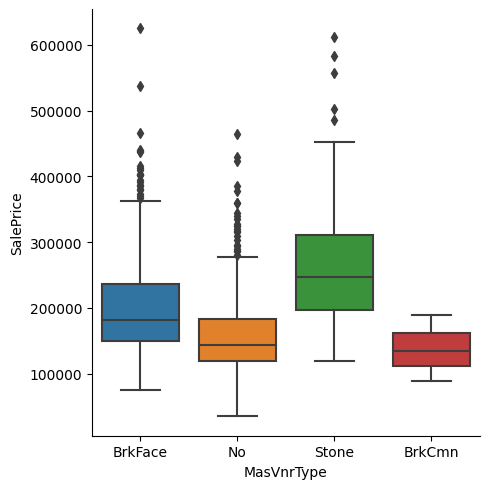

In [76]:
sns.catplot(data=train_df, x="MasVnrType", y="SalePrice", kind="box")

In [77]:
train_df['MasVnrArea'].fillna(0, inplace=True)
test_df['MasVnrArea'].fillna(0, inplace=True)

/tmp/ipykernel_30/3657060107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MasVnrArea'].fillna(0, inplace=True)
/tmp/ipykernel_30/3657060107.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [78]:
train_df['FireplaceQu'].unique()


array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [79]:
train_df['FireplaceQu'].fillna(0, inplace=True)
test_df['FireplaceQu'].fillna(0, inplace=True)

/tmp/ipykernel_30/2073847469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['FireplaceQu'].fillna(0, inplace=True)
/tmp/ipykernel_30/2073847469.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

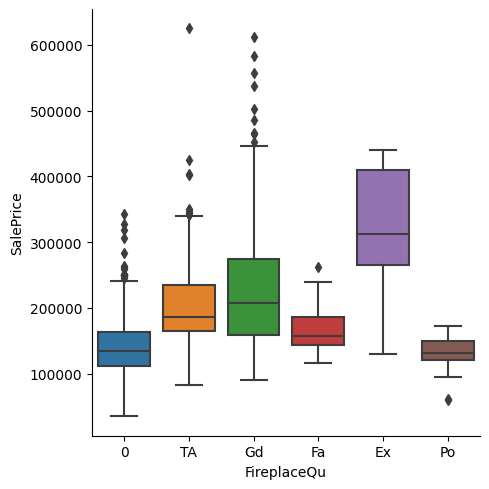

In [80]:
sns.catplot(data=train_df, x="FireplaceQu", y="SalePrice", kind="box")

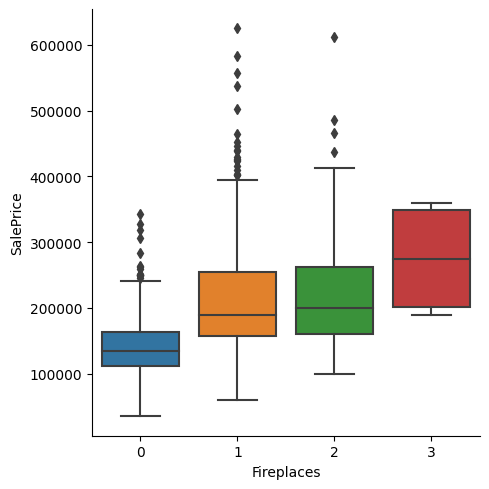

In [81]:
sns.catplot(data=train_df, x="Fireplaces", y="SalePrice", kind="box")


In [82]:
train_df['LotFrontage'].fillna(0, inplace=True)
test_df['LotFrontage'].fillna(0, inplace=True)


/tmp/ipykernel_30/3291190399.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['LotFrontage'].fillna(0, inplace=True)
/tmp/ipykernel_30/3291190399.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [83]:
train_df['GarageYrBlt'].corr(train_df['YearBuilt'])

0.8289827595060575

In [84]:
train_df['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [85]:
train_df['GarageCond'].fillna('No', inplace=True)
test_df['GarageCond'].fillna('No', inplace=True)

/tmp/ipykernel_30/1255948083.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageCond'].fillna('No', inplace=True)
/tmp/ipykernel_30/1255948083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

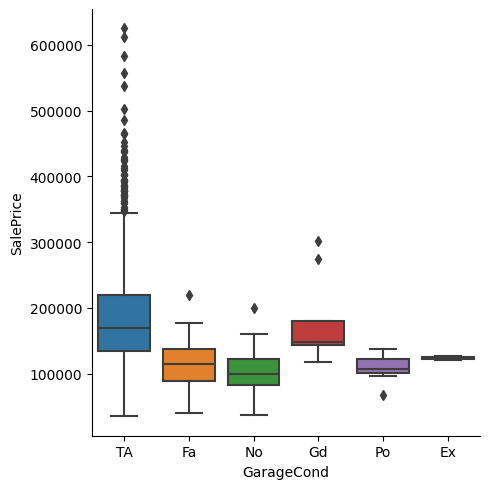

In [86]:
sns.catplot(data=train_df, x="GarageCond", y="SalePrice", kind="box")

/tmp/ipykernel_30/1877899387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageType'].fillna('No', inplace=True)
/tmp/ipykernel_30/1877899387.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

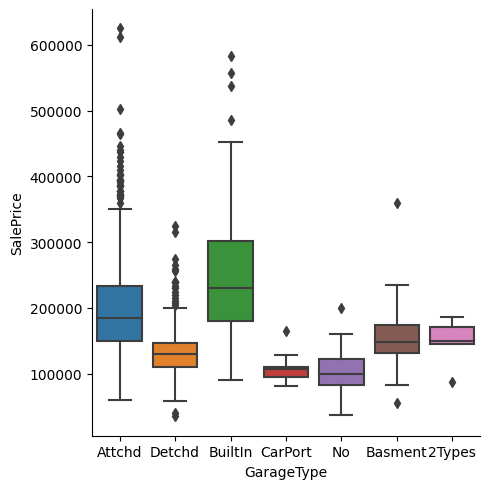

In [87]:
train_df['GarageType'].fillna('No', inplace=True)
test_df['GarageType'].fillna('No', inplace=True)
sns.catplot(data=train_df, x="GarageType", y="SalePrice", kind="box")

/tmp/ipykernel_30/3029075875.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageFinish'].fillna('No', inplace=True)
/tmp/ipykernel_30/3029075875.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

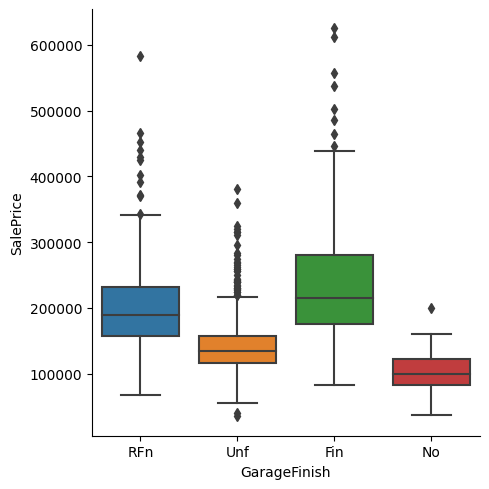

In [88]:
train_df['GarageFinish'].fillna('No', inplace=True)
test_df['GarageFinish'].fillna('No', inplace=True)
sns.catplot(data=train_df, x="GarageFinish", y="SalePrice", kind="box")

/tmp/ipykernel_30/2187484579.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageQual'].fillna('No', inplace=True)
/tmp/ipykernel_30/2187484579.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

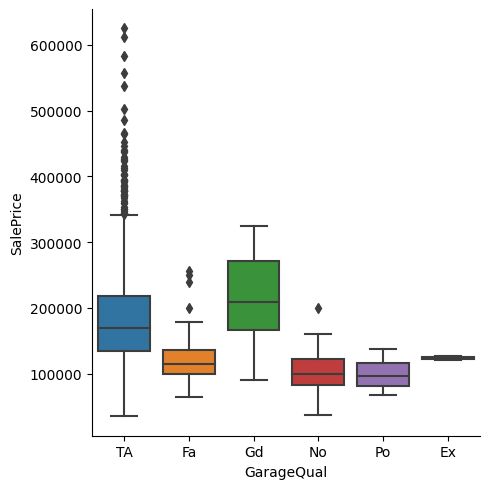

In [89]:
train_df['GarageQual'].fillna('No', inplace=True)
test_df['GarageQual'].fillna('No', inplace=True)
sns.catplot(data=train_df, x="GarageQual", y="SalePrice", kind="box")

In [90]:
train_df['BsmtFinType2'].unique()


array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [91]:
train_df['BsmtFinType2'].fillna('Unf', inplace=True)
test_df['BsmtFinType2'].fillna('Unf', inplace=True)


/tmp/ipykernel_30/2586836610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtFinType2'].fillna('Unf', inplace=True)
/tmp/ipykernel_30/2586836610.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

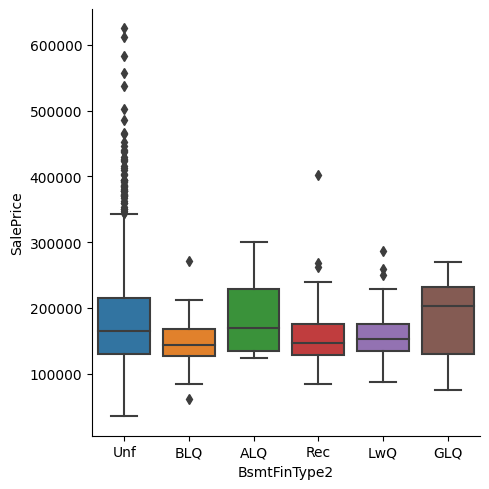

In [92]:
sns.catplot(data=train_df, x="BsmtFinType2", y="SalePrice", kind="box")

In [93]:
train_df['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [94]:
train_df['BsmtExposure'].fillna('No', inplace=True)
test_df['BsmtExposure'].fillna('No', inplace=True)

/tmp/ipykernel_30/2040818772.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtExposure'].fillna('No', inplace=True)
/tmp/ipykernel_30/2040818772.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

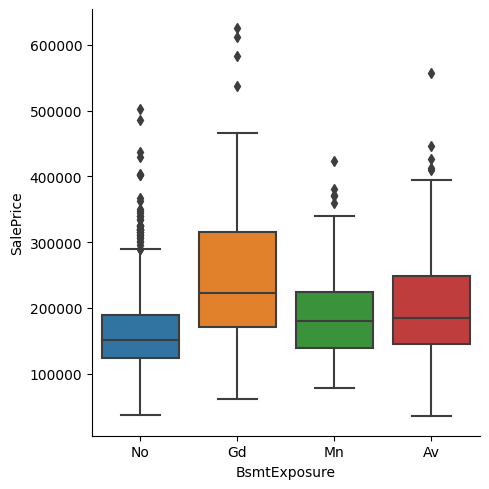

In [95]:
sns.catplot(data=train_df, x="BsmtExposure", y="SalePrice", kind="box")

In [96]:
train_df['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [97]:
train_df['BsmtQual'].fillna('No', inplace=True)
test_df['BsmtQual'].fillna('No', inplace=True)

/tmp/ipykernel_30/2878576625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtQual'].fillna('No', inplace=True)
/tmp/ipykernel_30/2878576625.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

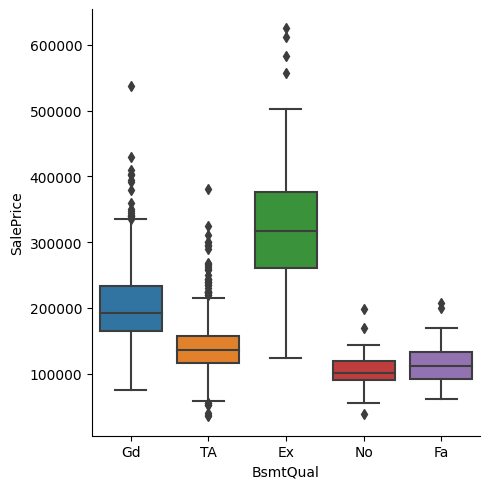

In [98]:
sns.catplot(data=train_df, x="BsmtQual", y="SalePrice", kind="box")

In [99]:
 train_df['BsmtCond'].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

/tmp/ipykernel_30/678150356.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtCond'].fillna('No', inplace=True)
/tmp/ipykernel_30/678150356.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

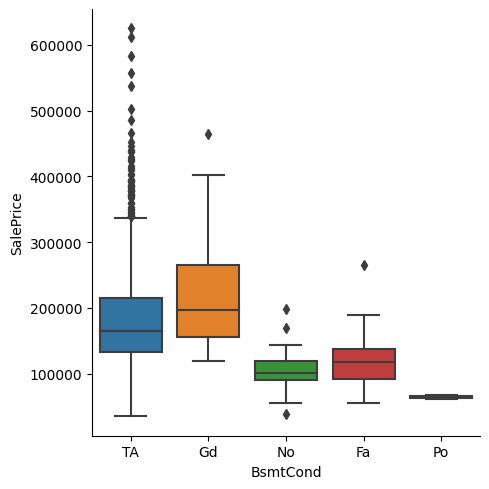

In [100]:
train_df['BsmtCond'].fillna('No', inplace=True)
test_df['BsmtCond'].fillna('No', inplace=True)
sns.catplot(data=train_df, x="BsmtCond", y="SalePrice", kind="box")

In [101]:
 train_df['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

/tmp/ipykernel_30/1973573967.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtFinType1'].fillna('Unf', inplace=True)
/tmp/ipykernel_30/1973573967.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

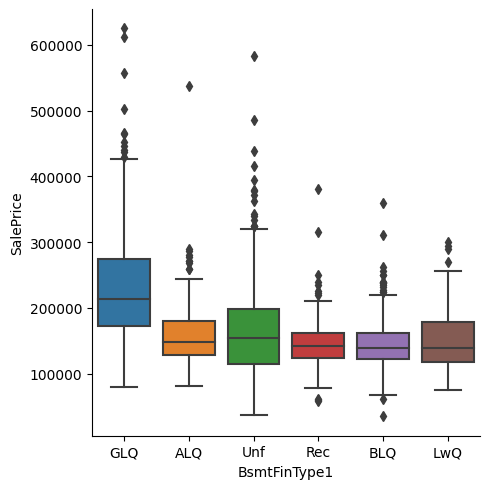

In [102]:
train_df['BsmtFinType1'].fillna('Unf', inplace=True)
test_df['BsmtFinType1'].fillna('Unf', inplace=True)
sns.catplot(data=train_df, x="BsmtFinType1", y="SalePrice", kind="box")

In [103]:
train_df['MasVnrArea'].fillna(0, inplace=True)
test_df['MasVnrArea'].fillna(0, inplace=True)


/tmp/ipykernel_30/117983875.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MasVnrArea'].fillna(0, inplace=True)
/tmp/ipykernel_30/117983875.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [104]:
train_df['Electrical'].fillna('SBrkr', inplace=True)
test_df['Electrical'].fillna('SBrkr', inplace=True)

/tmp/ipykernel_30/4245203846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Electrical'].fillna('SBrkr', inplace=True)
/tmp/ipykernel_30/4245203846.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## Drop unrelevant features


In [105]:
train_df = train_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])
test_df = test_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])

In [106]:
# Calculate house age by subtracting the year it was built from the year it was sold
train_df['houseage'] = train_df['YrSold'] - train_df['YearBuilt']
test_df['houseage'] = test_df['YrSold'] - test_df['YearBuilt']

In [107]:
# Calculate house remodel age by subtracting the last remodel year from the year it was sold
train_df['houseremodelage'] = train_df['YrSold'] - train_df['YearRemodAdd']
test_df['houseremodelage'] = test_df['YrSold'] - test_df['YearRemodAdd']

In [ ]:
# Create a total square footage feature by summing up different floor areas (1st floor, 2nd floor, and basement areas)
train_df['totalsf'] = train_df['1stFlrSF'] + train_df['2ndFlrSF'] + train_df['BsmtFinSF1'] + train_df['BsmtFinSF2']
test_df['totalsf'] = test_df['1stFlrSF'] + test_df['2ndFlrSF'] + test_df['BsmtFinSF1'] + test_df['BsmtFinSF2']

In [ ]:
# Create a total area feature by adding above-ground living area and basement area
train_df['totalarea'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']
test_df['totalarea'] = test_df['GrLivArea'] + test_df['TotalBsmtSF']

In [ ]:
# Create a total number of bathrooms feature by summing up full and half bathrooms from basement and above ground
# Half bathrooms are counted as 0.5 to reflect their smaller impact compared to full bathrooms
train_df['totalbaths'] = train_df['BsmtFullBath'] + train_df['FullBath'] + 0.5 * (train_df['BsmtHalfBath'] + train_df['HalfBath']) 
test_df['totalbaths'] = test_df['BsmtFullBath'] + test_df['FullBath'] + 0.5 * (test_df['BsmtHalfBath'] + test_df['HalfBath']) 


In [ ]:
# Create a total porch square footage feature by summing all porch-related areas
train_df['totalporchsf'] = train_df['OpenPorchSF'] + train_df['3SsnPorch'] + train_df['EnclosedPorch'] + train_df['ScreenPorch'] + train_df['WoodDeckSF']
test_df['totalporchsf'] = test_df['OpenPorchSF'] + test_df['3SsnPorch'] + test_df['EnclosedPorch'] + test_df['ScreenPorch'] + test_df['WoodDeckSF']

## Drop irrelevant or redundant features after feature engineering
- Features like 'YrSold', 'YearBuilt', 'YearRemodAdd' are removed since we have created 'houseage' and 'houseremodelage'
- Square footage features are replaced with combined total area features
- Porch-related features are replaced with 'totalporchsf'

In [ ]:
train_df = train_df.drop(columns=['Id','YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])
test_df = test_df.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])

In [ ]:
# Perform heatmap to visualize correlation between features
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
#drop GarageArea or GarageCars to prevent multicollinearity 
train_df = train_df.drop(columns=['GarageArea'])
test_df = test_df.drop(columns=['GarageArea'])

In [ ]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

In [ ]:
#perform log transformation as normalisation
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

In [ ]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

In [ ]:
train_df.dtypes[train_df.dtypes=='object']

In [ ]:
train_df.dtypes[train_df.dtypes !='object']

## Separate pipelines are used because different feature types require different preprocessing methods to ensure optimal model performance:

- Ordinal categorical (ode_cols): Encoded with Label Encoding or Ordinal Encoding to maintain the order of categories.
- Nominal categorical (ohe_cols): Transformed using One-Hot Encoding (OHE) to avoid introducing false ordinal relationships.
- Numerical (num_cols): Scaled or transformed to handle skewness and improve distribution.
  
    - Ensures appropriate handling of each feature type without introducing bias.
    - Prevents data leakage by applying transformations consistently across training and test sets.
    - Enhances model accuracy and interpretability by structuring preprocessing effectively.

In [ ]:
ode_cols = ['LotShape', 'LandContour','Utilities','LandSlope',  'BsmtQual',  'BsmtFinType1',  'CentralAir',  'Functional', \
           'FireplaceQu', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'BsmtExposure', 'HeatingQC','ExterQual', 'BsmtCond']

In [ ]:
ohe_cols = ['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', \
           'MasVnrType','Foundation',  'Electrical',  'SaleType', 'MSZoning', 'SaleCondition', 'Heating', 'GarageType', 'RoofMatl']

In [ ]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')

In [ ]:
#This pipeline is used for processing numerical columns, handling missing data, and scaling the data.
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')), #handled missing values by replacing the mean
    ('scaler', StandardScaler()) #scaling to mean =0 , standard deviation =1
])


In [ ]:
#This pipeline is used to handle ordinal categorical variables, impute missing values with the most frequent category, and encode the categories into numeric values.
ode_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),  # Fill missing values with the most common category
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))  # Convert categories into numerical order, assign -1 for unknown values
])


In [ ]:
#This pipeline handles nominal categorical features, imputes missing values with the most frequent category, and applies one-hot encoding to convert categories into binary features.


ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),  # Fill missing values with the most common category
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Convert categories into separate binary (0/1) columns, ignore unknown categories

])

In [ ]:
# Create a ColumnTransformer to apply different pipelines to different feature types
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols),  # Apply numerical pipeline to numerical columns
    ('ode_p', ode_pipeline, ode_cols),  # Apply ordinal encoding pipeline to ordinal categorical columns
    ('ohe_p', ohe_pipeline, ohe_cols),  # Apply one-hot encoding pipeline to nominal categorical columns
    ],
    remainder='passthrough',  # Leave other columns unchanged
    n_jobs=-1  # Utilize all CPU cores for parallel processing
)

In [ ]:
# Create a full preprocessing pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)  # Apply all transformations before feeding data into the model
])


## Fit dataset into mutiple model. explore it out

In [ ]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

In [ ]:
print(X.dtypes)


In [ ]:
# Convert mixed-type columns to string type for the specified columns
for col in ode_cols + ohe_cols:
    X[col] = X[col].astype(str)


In [ ]:
X_preprocessed = pipeline.fit_transform(X)

In [ ]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

## Linear Regression Model

In [ ]:

# Build a Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Make predictions
y_pred_lr = lr.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred_lr)

# Print results
print("Linear Regression Model Evaluation")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print("-" * 40)

# Calculate residuals
residuals = y_test - y_pred_lr

# Plot residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color="red", linestyle="dashed")
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Residual plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="dashed")
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


## Random Forest Model 

In [ ]:
from sklearn.model_selection import GridSearchCV


# Initialize Random Forest Regressor
RFR = RandomForestRegressor(random_state=13)

# Define hyperparameter grid
param_grid_RFR = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500],
    'min_samples_split': [3, 5, 10]
}

# Perform Grid Search with 5-fold Cross Validation
rfr_cv = GridSearchCV(RFR, param_grid_RFR, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rfr_cv.fit(X_train, y_train)

# Get best parameters and best RMSE from cross-validation
best_params = rfr_cv.best_params_
best_rmse = np.sqrt(-1 * rfr_cv.best_score_)

# Train model using the best parameters
best_rfr = rfr_cv.best_estimator_

# Make predictions on test data
y_pred_rfr = best_rfr.predict(X_test)

# Compute evaluation metrics
r2_rfr = r2_score(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)
mape_rfr = mean_absolute_percentage_error(y_test, y_pred_rfr) * 100  # Convert to percentage

# Print results
print("Random Forest Model Evaluation")
print(f"Best Parameters: {best_params}")
print(f"Best RMSE (Cross-Validation): {best_rmse:.2f}")
print(f"Test R² Score: {r2_rfr:.4f}")
print(f"Test RMSE: {rmse_rfr:.2f}")
print(f"Test MAPE: {mape_rfr:.2f}%")
print("-" * 40)

# Compute residuals
residuals_rfr = y_test - y_pred_rfr

# Plot residual distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rfr, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

# Plot residuals vs predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rfr, residuals_rfr, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

## XGBoost Regression Model

In [ ]:
# Initialize XGBoost Regressor
XGB = XGBRegressor(random_state=13)

# Define hyperparameter grid
param_grid_XGB = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1, 2, 3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
}

# Perform Grid Search with 3-fold Cross Validation
xgb_cv = GridSearchCV(XGB, param_grid_XGB, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

# Get best parameters and best RMSE from cross-validation
best_params_xgb = xgb_cv.best_params_
best_rmse_xgb = np.sqrt(-1 * xgb_cv.best_score_)

# Train model using the best parameters
best_xgb = xgb_cv.best_estimator_

# Make predictions on test data
y_pred_xgb = best_xgb.predict(X_test)

# Compute evaluation metrics
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100  # Convert to percentage

# Print results
print("XGBoost Model Evaluation")
print(f"Best Parameters: {best_params_xgb}")
print(f"Best RMSE (Cross-Validation): {best_rmse_xgb:.2f}")
print(f"Test R² Score: {r2_xgb:.4f}")
print(f"Test RMSE: {rmse_xgb:.2f}")
print(f"Test MAPE: {mape_xgb:.2f}%")
print("-" * 40)

# Compute residuals
residuals_xgb = y_test - y_pred_xgb

# Plot residual distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_xgb, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

# Plot residuals vs predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

## Ridge Model 

In [ ]:
# Standardize features to avoid scaling issues
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Ridge Regression model
ridge = Ridge()

# Define hyperparameter grid
param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}

# Perform Grid Search with 5-fold Cross Validation
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train)  # Ensure X_train is scaled if necessary

# Get best model from GridSearch
best_ridge = ridge_cv.best_estimator_

# Make predictions on test data
y_pred_ridge= best_ridge.predict(X_test_scaled)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mape = mean_absolute_percentage_error(y_test,y_pred_ridge) * 100  # Convert to %
r2 = r2_score(y_test, y_pred_ridge)

# Print results
print(f"Best Ridge Parameters: {ridge_cv.best_params_}")
print(f"Best RMSE (CV): {np.sqrt(-1 * ridge_cv.best_score_):.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


# Compute residuals
residuals_ridge = y_test - y_pred_ridge

# Plot residual distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_ridge, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

# Plot residuals vs predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

## Gradient Boosting Regressor

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Initialize Gradient Boosting Regressor with early stopping
GBR = GradientBoostingRegressor(n_estimators=1000,  # Large but will stop early
                                validation_fraction=0.1,  # Use 10% of data for early stopping
                                n_iter_no_change=10,  # Stop if no improvement for 10 rounds
                                tol=0.001)  # Tolerance for stopping

# Define hyperparameter search space
param_grid_GBR = {
    'max_depth': [10, 15, 20],
    'n_estimators': [100, 300, 500],  # Reduced range
    'min_samples_leaf': [10, 25, 50],
    'learning_rate': [0.01, 0.05, 0.1],  # Removed very low 0.001
    'max_features': [0.3, 0.7]  # Focus on fewer options
}

# Use RandomizedSearchCV instead of GridSearchCV (much faster)
GBR_cv = RandomizedSearchCV(GBR, param_distributions=param_grid_GBR, 
                            n_iter=30,  # Test only 30 random combinations
                            cv=3,  # Fewer folds (was 5)
                            scoring='neg_mean_squared_error', 
                            n_jobs=-1,  # Parallel processing
                            random_state=42, 
                            verbose=1)

# Fit model
GBR_cv.fit(X_train, y_train)

# Best model
best_GBR = GBR_cv.best_estimator_

# Predictions
y_pred_GBR = best_GBR.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_GBR))
r2 = r2_score(y_test, y_pred_GBR)

# Avoid division by zero in MAPE
mape = np.mean(np.abs((y_test - y_pred_GBR) / np.where(y_test == 0, 1e-9, y_test))) * 100

# Print results
print(f"Best GBR Parameters: {GBR_cv.best_params_}")
print(f"Best RMSE (CV): {np.sqrt(-GBR_cv.best_score_):.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Compute residuals
residuals_GBR = y_test - y_pred_GBR

# Plot residuals
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_GBR, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.subplot(1, 2, 2)
plt.scatter(y_pred_GBR, residuals_GBR, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()


## Lightgbm model 

In [ ]:
from lightgbm import LGBMRegressor

# Initialize the regressor
lgbm_regressor = LGBMRegressor()

# Define the parameter grid
param_grid_lgbm = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

# Set up GridSearchCV with cross-validation
lgbm_cv = GridSearchCV(lgbm_regressor, param_grid_lgbm, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_cv.fit(X_train, y_train)

# Get the best model
best_lgbm = lgbm_cv.best_estimator_

# Predictions on test data
y_pred_lgbm = best_lgbm.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2 = r2_score(y_test, y_pred_lgbm)
mape = mean_absolute_percentage_error(y_test, y_pred_lgbm) * 100

# Print results
print(f"Best LGBM Parameters: {lgbm_cv.best_params_}")
print(f"Best RMSE (CV): {np.sqrt(-lgbm_cv.best_score_):.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Compute residuals
residuals_lgbm = y_test - y_pred_lgbm

# Plot residual distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_pred_lgbm, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

# Plot residuals vs predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_lgbm, residuals_lgbm, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

## Catboost Model

In [ ]:
# Import the necessary module
from catboost import CatBoostRegressor


In [ ]:

# Initialize the CatBoost Regressor
catboost = CatBoostRegressor(loss_function='RMSE', verbose=False)

# Define the parameter grid
param_grid_cat = {
    'iterations': [100, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

# Set up GridSearchCV with cross-validation
cat_cv = GridSearchCV(catboost, param_grid_cat, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
cat_cv.fit(X_train, y_train)

# Get the best model
best_catboost = cat_cv.best_estimator_

# Predictions on test data
y_pred_catboost = best_catboost.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_catboost))
r2 = r2_score(y_test, y_pred_catboost)
mape = mean_absolute_percentage_error(y_test, y_pred_catboost) * 100

# Print results
print(f"Best CatBoost Parameters: {cat_cv.best_params_}")
print(f"Best RMSE (CV): {np.sqrt(-cat_cv.best_score_):.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Compute residuals
residuals_ridge = y_test - y_pred_catboost

# Plot residual distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_pred_catboost, bins=50, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

# Plot residuals vs predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_catboost, residuals_ridge, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

## Compare the performance of each model across different metrics.
- RMSE (Root Mean Squared Error) → Lower is better
-  R² (Coefficient of Determination) → Higher is better
- MAPE (Mean Absolute Percentage Error) → Lower is better

In [ ]:

# Store model results
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Ridge Regression","Gradient Boost Regressor", "LightGBM", "CatBoost"],
    "RMSE": [738505019.96, 0.14, 0.12, 0.12,0.1216 , 0.1313, 0.1196],  
    "R²": [-3741447406358658560.00, 0.8675, 0.8952, 0.9020,0.8985 ,0.8817, 0.9018],
    "MAPE(%)": [500087142.19, 80.14, 71.16, 69.36,67.61, 75.06, 69.50]
}

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Display the DataFrame
df_results


### Best Model Based on the Comparison
The best-performing model is **CatBoost**, as it has:  
- **Lowest RMSE** (1.196e-01) → Indicates minimal prediction error.  
- **Highest R² Score** (0.9018) → Shows strong predictive power.  
- **Lowest MAPE** (69.5%) → Suggests better relative accuracy compared to others.  

### **Why is CatBoost the Best?**
- 1️. **Handles Categorical Features Well** – Unlike Linear Regression, which struggles with non-linearity.  
- 2️. **Robust to Outliers** – Gradient boosting methods are less sensitive to extreme values.  
- 3️. **Better Generalization** – Prevents overfitting while capturing complex patterns.
- 4️. **Regularization & Feature Selection** – Reduces noise and improves prediction stability.  

Overall, **CatBoost** outperforms all models in accuracy and stability.


### Reasons why your Linear Regression metrics are extremely large:

- 1️. Data Scaling Issues – Feature values vary greatly, leading to unstable coefficients.
- 2️. Extreme Outliers – Large deviations in y_train or y_test distort predictions.
- 3️. Poor Feature Selection – Irrelevant or highly correlated features negatively impact the model.
- 4️. Non-Linear Relationships – Linear Regression assumes linearity; real-world data often isn't.
- 5️. High Multicollinearity – Strong correlations between independent variables cause instability.

## Feature Importance Analysis

### 🎯 What is Feature Importance?
Feature importance helps determine which input variables (features) have the most impact on the target variable in a predictive model. This analysis enhances model interpretability and can guide feature selection.

---

### 📌 Why Perform Feature Importance Analysis?
✅ Identify key predictors affecting the outcome.  
✅ Reduce dimensionality by eliminating less important features.  
✅ Improve model interpretability and trustworthiness.  
✅ Enhance model efficiency by reducing overfitting.  

---

### 🔥 When to Use Each Method?
| Method | Best For | Pros | Cons |
|--------|---------|------|------|
| **Tree-based** | Tree models | Fast, built-in | Biased toward high-cardinality features |
| **SHAP** | Any model | Detailed insights | Computationally expensive |
| **Permutation** | Any model | Model-agnostic | Slower for large datasets |

---

### 🚀 Next Steps
- Analyze the results: Do the most important features make sense?
- Consider dropping low-importance features to improve efficiency.
- If interpretability is crucial, SHAP may be the best choice.



In [ ]:

# Ensure X_train is a DataFrame before extracting column names
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]  print(type(X_train))  # Check if it's a DataFrame or NumPy array
print(X_train.shape)  # Check dimensions
if isinstance(X_train, pd.DataFrame):
    print(X_train.columns)  # Print column names if it's a DataFrame


# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
})

# Sort by importance (descending order)
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost Model")
plt.show()



In [ ]:
print(type(X_train))  # Check if it's a DataFrame or NumPy array
print(X_train.shape)  # Check dimensions
if isinstance(X_train, pd.DataFrame):
    print(X_train.columns)  # Print column names if it's a DataFrame


### **What is VotingRegressor?**  
- `VotingRegressor` is an ensemble technique that **combines multiple regression models** to make a final prediction by averaging their outputs.  
- This approach helps improve **model performance, reduce variance, and create a more stable prediction** compared to using a single model.  


In [ ]:
# Import the necessary module
from sklearn.ensemble import VotingRegressor
vr = VotingRegressor([('gbr', GBR_cv.best_estimator_),
                      ('xgb', xgb_cv.best_estimator_),
                      ('ridge', ridge_cv.best_estimator_)],
                    weights=[2,3,1])


In [ ]:
vr.fit(X_train, y_train)


In [ ]:
y_pred_vr = vr.predict(X_test)

In [ ]:
mean_squared_error(y_test, y_pred_vr, squared=False)


### **What is Stacking Regressor?**  
- `Stacking Regressor` is an **ensemble learning technique** that **combines multiple base models (estimators)** and feeds their predictions into a **meta-model** (final estimator) to make a final prediction.  
- Unlike `VotingRegressor`, which **averages predictions**, Stacking trains a **meta-model** on the predictions of base models to learn an optimal combination.  

### **Difference Between Voting and Stacking Regressor (In Simple Terms)**

Voting Regressor: Think of it like a group decision where multiple models make predictions, and we take the average (or weighted average) of their outputs. It doesn't learn from the predictions—it just combines them.

Stacking Regressor: Imagine a team project where each team member (model) gives their opinion, and then a team leader (meta-model) looks at their answers and decides the final output. The meta-model learns which models are more reliable in different situations, improving accuracy.


## **When to Use Stacking?**  
- When different models **capture different patterns** in the data.  
- If individual models perform well but **combining them could improve accuracy**.  
- When a dataset has **complex relationships that a single model might miss**.  


In [ ]:
estimators = [
    ('gbr', GBR_cv.best_estimator_),
    ('xgb', xgb_cv.best_estimator_),
    ('cat', cat_cv.best_estimator_),
    ('lgb', lgbm_cv.best_estimator_),
    ('rfr', rfr_cv.best_estimator_),
]


In [ ]:
#Import the necessary module
from sklearn.ensemble import StackingRegressor
stackreg = StackingRegressor(
            estimators = estimators,
            final_estimator = vr
)


In [ ]:

stackreg.fit(X_train, y_train)

In [ ]:
y_pred_stack = stackreg.predict(X_test)

In [ ]:
mean_squared_error(y_test, y_pred_stack, squared=False)

In [ ]:
df_test_preprocess = pipeline.transform(test_df)

In housing price prediction, the best model is the one with the lowest RMSE (Root Mean Squared Error) because a lower RMSE means better accuracy in predicting house prices.

Based on model results:

- Ridge Regression: 0.112977 **(Lowest RMSE)**
- Gradient Boosting Regressor (GBR): 0.113523
- CatBoost: 0.115289
- XGBoost (XGB): 0.117083
- Voting Regressor: 0.117737
- Stacking Regressor: 0.118517
- LightGBM (LGBM): 0.123941
- Random Forest Regressor (RFR): 0.131522
- Linear Regression: 5.43896 **(Worst)**
  
### Best Model: Ridge Regression (0.112977) 

In [ ]:
y_stacking = np.exp(ridge_cv.predict(df_test_preprocess))

# Creating a new DataFrame with the 'Id' column
df_y_stacking_out = test_df[['Id']].copy()  # Use .copy() to avoid modifying the original DataFrame

# Safely assign the 'SalePrice' column using .loc[]
df_y_stacking_out.loc[:, 'SalePrice'] = y_stacking

# Save the results to a CSV file
df_y_stacking_out.to_csv('submission.csv', index=False)


In [ ]:
print("First 20 predicted house prices:")
df_y_stacking_out[:20]